# 0.8 Glamsterdam-Only EIP-8037 Passive Replay

This notebook replays the pure Glamsterdam / EIP-8037-as-shipped baseline for the current 500-block sample.

State remains under the shared execution/state bottleneck:

```text
gas_used_8037 = max(execution_gas_used, state_gas_8037)
```

The shared base fee uses the ordinary EIP-1559 linear update with denominator 8:

```text
base_fee[n + 1] = update_1559(base_fee[n], min(gas_used_8037[n], execution_state_limit))
```

`base_fee_with_8037` is seeded to the first historical block's `base_fee_per_gas`. Each block reports the base fee entering that block. The raw bottleneck usage remains visible as `gas_used_8037`, while the fee update uses `gas_used_8037_for_base_fee = min(gas_used_8037, 60M)` so each step is bounded by the ordinary EIP-1559 maximum change.

## Setup

In [1]:
import os
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib-cache"))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from basefee.eip1559 import update_eip1559_base_fee

pd.options.display.float_format = "{:,.4f}".format
plt.style.use("seaborn-v0_8-whitegrid")

## Parameters

The replay uses the configured block range from the Xatu state-growth pull and RPC state-growth calibration. The execution/state target is `30M` gas with a `60M` shared limit for validity diagnostics. Bandwidth columns are joined only when the matching bandwidth CSV exists.

In [2]:
START_BLOCK = 24_120_001
END_BLOCK = 24_120_500
EXECUTION_STATE_TARGET = 30_000_000
EXECUTION_STATE_LIMIT = 60_000_000

HISTORICAL_STORAGE_SET_GAS = 20_000
HISTORICAL_NEW_ACCOUNT_GAS = 25_000
HISTORICAL_CODE_DEPOSIT_GAS_PER_BYTE = 200
HISTORICAL_AUTH_BASE_GAS = 12_500

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

XATU_STATE_CSV = DATA_DIR / f"xatu_state_growth_{START_BLOCK}_{END_BLOCK}.csv"
STATE_REPLAY_CSV = DATA_DIR / f"state_gas_for_replay_{START_BLOCK}_{END_BLOCK}.csv"
BANDWIDTH_CSV = DATA_DIR / f"bandwidth_content_8131_{START_BLOCK}_{END_BLOCK}.csv"
OUT_REPLAY_CSV = DATA_DIR / f"glamsterdam_only_replay_{START_BLOCK}_{END_BLOCK}.csv"
OUT_SUMMARY_CSV = DATA_DIR / f"glamsterdam_only_replay_summary_{START_BLOCK}_{END_BLOCK}.csv"
OUT_CURRENT_GAS_PLOT = PLOTS_DIR / f"glamsterdam_only_current_gas_{START_BLOCK}_{END_BLOCK}.png"
OUT_8037_GAS_PLOT = PLOTS_DIR / f"glamsterdam_only_8037_gas_{START_BLOCK}_{END_BLOCK}.png"
OUT_BASE_FEE_PLOT = PLOTS_DIR / f"glamsterdam_only_base_fee_comparison_{START_BLOCK}_{END_BLOCK}.png"
OUT_RATIO_PLOT = PLOTS_DIR / f"glamsterdam_only_base_fee_ratio_{START_BLOCK}_{END_BLOCK}.png"

for path in [XATU_STATE_CSV, STATE_REPLAY_CSV]:
    if not path.exists():
        raise FileNotFoundError(path)

START_BLOCK, END_BLOCK, EXECUTION_STATE_TARGET, EXECUTION_STATE_LIMIT

(24120001, 24120500, 30000000, 60000000)

## Build Passive Replay Inputs

`state_gas_8037` comes from the RPC/prestateTracer counterfactual EIP-8037 estimator. `execution_gas_used` subtracts only the historical state-creation cost that EIP-8037 reprices:

```text
historical_state_creation_gas = 20_000 * new_storage_slots + 25_000 * new_accounts + 200 * code_bytes + 12_500 * new_delegation_indicators
execution_gas_used = historical gas_used - historical_state_creation_gas
```

Then the replay replaces the historical state-growth component with the counterfactual EIP-8037 state gas through the bottleneck rule:

```text
gas_used_8037 = max(execution_gas_used, state_gas_8037)
```

The CBT `gas_state_growth` column is retained as a diagnostic, but it is too broad for this subtraction because it includes non-creation state/access activity that remains in the execution dimension.

`gas_used_8037` is the raw passive diagnostic and can exceed the staged `60M` limit. The base-fee update uses a capped `gas_used_8037_for_base_fee = min(gas_used_8037, 60M)`, because a real valid block cannot exceed the limit; an over-limit historical block would have had to shed state and would update the fee like a full block.

This keeps historical execution demand fixed while repricing state creation under EIP-8037.

In [3]:
xatu = pd.read_csv(XATU_STATE_CSV)
state = pd.read_csv(STATE_REPLAY_CSV)

inputs = (
    xatu[
        [
            "block_number",
            "timestamp",
            "gas_used",
            "gas_limit",
            "base_fee_per_gas",
            "gas_state_growth",
        ]
    ]
    .merge(state, on="block_number", how="inner", validate="one_to_one")
    .sort_values("block_number")
    .reset_index(drop=True)
)

if BANDWIDTH_CSV.exists():
    bandwidth = pd.read_csv(BANDWIDTH_CSV)
    inputs = inputs.merge(
        bandwidth[
            [
                "block_number",
                "bandwidth_gas",
                "bandwidth_metered_bytes",
                "calldata_gas",
                "bal_gas",
                "calldata_bytes",
                "bal_rlp_bytes",
            ]
        ],
        on="block_number",
        how="left",
        validate="one_to_one",
    )
    inputs["bandwidth_bytes"] = inputs["bandwidth_metered_bytes"].astype("Int64")
else:
    for column in [
        "bandwidth_gas",
        "bandwidth_metered_bytes",
        "calldata_gas",
        "bal_gas",
        "calldata_bytes",
        "bal_rlp_bytes",
        "bandwidth_bytes",
    ]:
        inputs[column] = pd.NA

inputs["current_gas_used"] = inputs["gas_used"].astype("int64")
inputs["historical_state_creation_gas"] = (
    inputs["new_storage_slots"].astype("int64") * HISTORICAL_STORAGE_SET_GAS
    + inputs["new_accounts"].astype("int64") * HISTORICAL_NEW_ACCOUNT_GAS
    + inputs["code_bytes"].astype("int64") * HISTORICAL_CODE_DEPOSIT_GAS_PER_BYTE
    + inputs["new_delegation_indicators"].astype("int64") * HISTORICAL_AUTH_BASE_GAS
)
inputs["execution_gas_used"] = (
    inputs["current_gas_used"]
    - inputs["historical_state_creation_gas"]
)
inputs["state_gas_8037"] = inputs["state_gas_used_for_replay"].astype("int64")
inputs["gas_used_8037"] = inputs[["execution_gas_used", "state_gas_8037"]].max(axis=1)
inputs["bottleneck"] = "state"
inputs.loc[inputs["execution_gas_used"] > inputs["state_gas_8037"], "bottleneck"] = "execution"
inputs.loc[inputs["execution_gas_used"] == inputs["state_gas_8037"], "bottleneck"] = "tied"
inputs["execution_state_gas_target"] = EXECUTION_STATE_TARGET
inputs["execution_state_gas_limit"] = EXECUTION_STATE_LIMIT
inputs["gas_used_8037_limit_exceeded"] = inputs["gas_used_8037"] > EXECUTION_STATE_LIMIT
inputs["gas_used_8037_for_base_fee"] = inputs["gas_used_8037"].clip(upper=EXECUTION_STATE_LIMIT)

if (inputs["execution_gas_used"] < 0).any():
    bad = inputs.loc[inputs["execution_gas_used"] < 0, "block_number"].tolist()
    raise RuntimeError(f"negative execution_gas_used after state creation de-accounting: {bad[:10]}")


inputs[
    [
        "block_number",
        "current_gas_used",
        "gas_state_growth",
        "historical_state_creation_gas",
        "execution_gas_used",
        "state_gas_8037",
        "gas_used_8037",
        "gas_used_8037_for_base_fee",
        "base_fee_per_gas",
    ]
].head()

,block_number,current_gas_used,gas_state_growth,historical_state_creation_gas,execution_gas_used,state_gas_8037,gas_used_8037,gas_used_8037_for_base_fee,base_fee_per_gas
0,24120001,59964904,23065872,7384500,52580404,42310620,52580404,52580404,65765607
1,24120002,13753679,7197200,2420000,11333679,13693500,13693500,13693500,73976706
2,24120003,41015898,21379907,7778400,33237498,43098570,43098570,43098570,68969001
3,24120004,23756933,11842630,5440400,18316533,31432320,31432320,31432320,72134648
4,24120005,16941785,9414948,2364900,14576885,13558860,14576885,14576885,70258226


## Replay

In [4]:
base_fees = []
base_fee = int(inputs["base_fee_per_gas"].iloc[0])
for row in inputs.itertuples(index=False):
    base_fees.append(base_fee)
    base_fee = update_eip1559_base_fee(
        parent_base_fee=base_fee,
        gas_used=int(row.gas_used_8037_for_base_fee),
        gas_target=EXECUTION_STATE_TARGET,
        min_base_fee=1,
    )

replay = inputs.rename(
    columns={
        "base_fee_per_gas": "original_base_fee",
    }
).copy()
replay["base_fee_with_8037"] = base_fees
replay["base_fee_delta_8037_minus_original"] = (
    replay["base_fee_with_8037"] - replay["original_base_fee"]
)
replay["base_fee_ratio_8037_to_original"] = (
    replay["base_fee_with_8037"] / replay["original_base_fee"]
)
replay["execution_gas_source"] = "historical_gas_used_minus_historical_state_creation_cost"
replay["replay_note"] = "base_fee_with_8037 seeded to first historical base_fee; block n min(gas_used_8037, 60M limit) updates block n+1 fee against 30M target"

ordered_cols = [
    "block_number",
    "timestamp",
    "current_gas_used",
    "gas_limit",
    "original_base_fee",
    "gas_state_growth",
    "historical_state_creation_gas",
    "execution_gas_used",
    "execution_gas_source",
    "state_gas_8037",
    "state_gas_source",
    "gas_used_8037",
    "gas_used_8037_for_base_fee",
    "execution_state_gas_target",
    "execution_state_gas_limit",
    "gas_used_8037_limit_exceeded",
    "base_fee_with_8037",
    "base_fee_delta_8037_minus_original",
    "base_fee_ratio_8037_to_original",
    "bottleneck",
    "bandwidth_gas",
    "bandwidth_bytes",
    "replay_note",
]
replay = replay[ordered_cols]
replay.to_csv(OUT_REPLAY_CSV, index=False)

replay[
    [
        "block_number",
        "execution_gas_used",
        "state_gas_8037",
        "gas_used_8037",
        "original_base_fee",
        "base_fee_with_8037",
        "base_fee_ratio_8037_to_original",
        "bottleneck",
    ]
].head(10)

,block_number,execution_gas_used,state_gas_8037,gas_used_8037,original_base_fee,base_fee_with_8037,base_fee_ratio_8037_to_original,bottleneck
0,24120001,52580404,42310620,52580404,65765607,65765607,1.0000,execution
1,24120002,11333679,13693500,13693500,73976706,71953165,0.9726,state
2,24120003,33237498,43098570,43098570,68969001,67064398,0.9724,state
3,24120004,18316533,31432320,31432320,72134648,70724596,0.9805,state
4,24120005,14576885,13558860,14576885,70258226,71146680,1.0126,execution
5,24120006,19498938,85770270,85770270,66435531,66574583,1.0021,state
6,24120007,3194839,4430880,4430880,67390635,74896405,1.1114,state
7,24120008,29425457,58360320,58360320,60068879,66917092,1.1140,state
8,24120009,18669399,52833960,52833960,62568058,74824550,1.1959,state
9,24120010,27581529,77177790,77177790,62095168,81943469,1.3196,state


## Summary

In [5]:
base_fee_step_change = replay["base_fee_with_8037"].pct_change()

summary = pd.DataFrame(
    [
        {
            "blocks": len(replay),
            "execution_bottleneck_blocks": int((replay["bottleneck"] == "execution").sum()),
            "state_bottleneck_blocks": int((replay["bottleneck"] == "state").sum()),
            "mean_current_gas_used": float(replay["current_gas_used"].mean()),
            "mean_cbt_gas_state_growth": float(replay["gas_state_growth"].mean()),
            "mean_historical_state_creation_gas": float(replay["historical_state_creation_gas"].mean()),
            "mean_execution_gas_used": float(replay["execution_gas_used"].mean()),
            "mean_state_gas_8037": float(replay["state_gas_8037"].mean()),
            "mean_gas_used_8037": float(replay["gas_used_8037"].mean()),
            "mean_gas_used_8037_for_base_fee": float(replay["gas_used_8037_for_base_fee"].mean()),
            "max_gas_used_8037": int(replay["gas_used_8037"].max()),
            "max_gas_used_8037_for_base_fee": int(replay["gas_used_8037_for_base_fee"].max()),
            "target_exceed_blocks": int((replay["gas_used_8037"] > EXECUTION_STATE_TARGET).sum()),
            "limit_exceed_blocks": int((replay["gas_used_8037"] > EXECUTION_STATE_LIMIT).sum()),
            "initial_original_base_fee": int(replay["original_base_fee"].iloc[0]),
            "initial_base_fee_with_8037": int(replay["base_fee_with_8037"].iloc[0]),
            "final_original_base_fee": int(replay["original_base_fee"].iloc[-1]),
            "final_base_fee_with_8037": int(replay["base_fee_with_8037"].iloc[-1]),
            "mean_base_fee_ratio_8037_to_original": float(replay["base_fee_ratio_8037_to_original"].mean()),
            "min_base_fee_ratio_8037_to_original": float(replay["base_fee_ratio_8037_to_original"].min()),
            "max_base_fee_ratio_8037_to_original": float(replay["base_fee_ratio_8037_to_original"].max()),
            "max_base_fee_step_increase_pct": float(base_fee_step_change.max(skipna=True)),
            "max_base_fee_step_decrease_pct": float((-base_fee_step_change).max(skipna=True)),
        }
    ]
)
summary.to_csv(OUT_SUMMARY_CSV, index=False)

bottleneck_shares = (
    replay["bottleneck"]
    .value_counts()
    .rename_axis("bottleneck")
    .reset_index(name="blocks")
)
bottleneck_shares["share"] = bottleneck_shares["blocks"] / len(replay)

display(summary)
display(bottleneck_shares)

,blocks,execution_bottleneck_blocks,state_bottleneck_blocks,mean_current_gas_used,mean_cbt_gas_state_growth,mean_historical_state_creation_gas,mean_execution_gas_used,mean_state_gas_8037,mean_gas_used_8037,mean_gas_used_8037_for_base_fee,...,limit_exceed_blocks,initial_original_base_fee,initial_base_fee_with_8037,final_original_base_fee,final_base_fee_with_8037,mean_base_fee_ratio_8037_to_original,min_base_fee_ratio_8037_to_original,max_base_fee_ratio_8037_to_original,max_base_fee_step_increase_pct,max_base_fee_step_decrease_pct
0,500,244,256,"30,470,641.8200","14,250,467.9260","4,935,712.6000","25,534,929.2200","28,665,593.4600","32,500,652.1120","31,326,490.9920",...,28,65765607,65765607,77089929,408145462,3.5073,0.9724,6.9100,0.1250,0.1115


,bottleneck,blocks,share
0,state,256,0.5120
1,execution,244,0.4880


## Plots

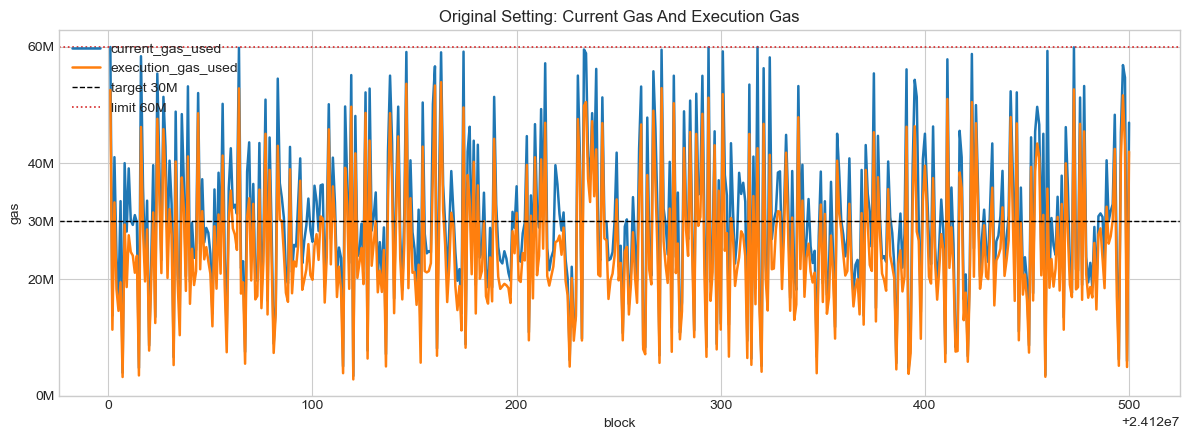

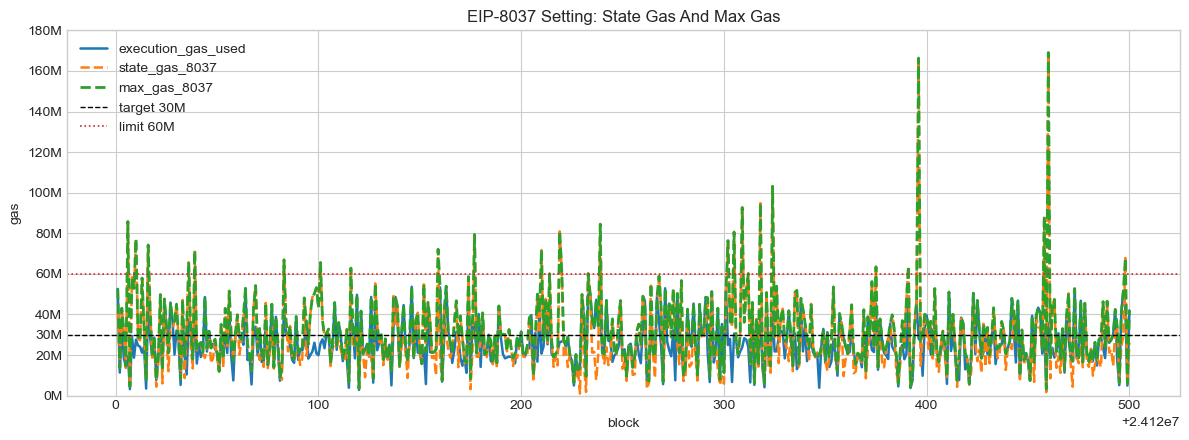

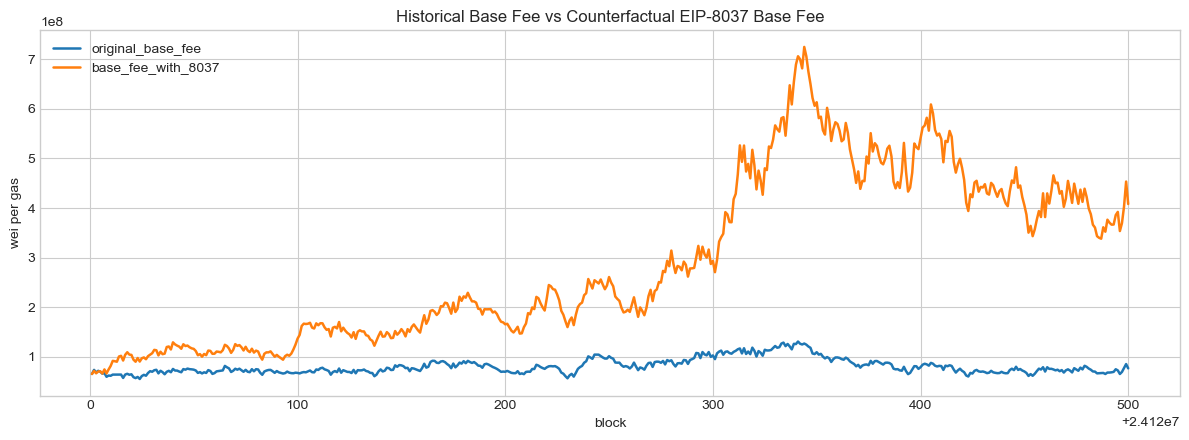

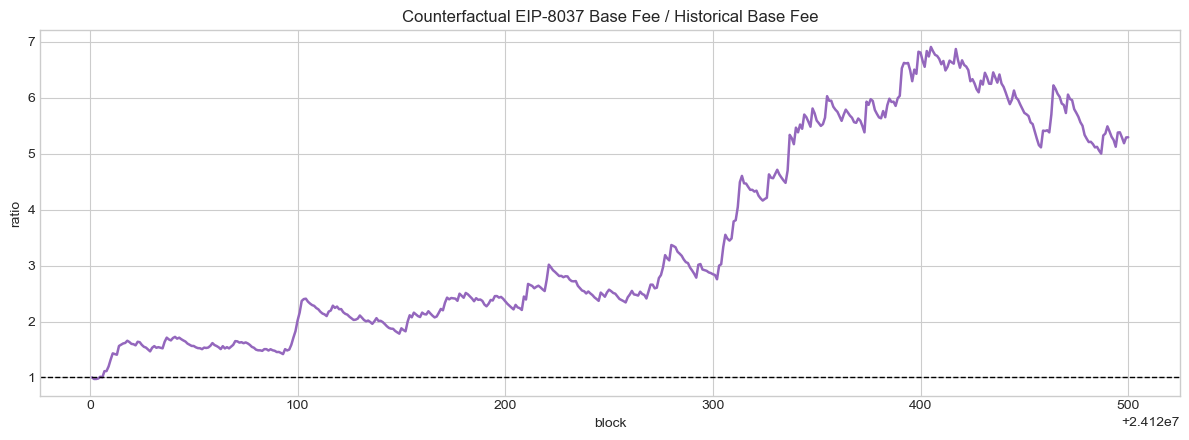

(PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/glamsterdam_only_current_gas_24120001_24120500.png'),
 PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/glamsterdam_only_8037_gas_24120001_24120500.png'),
 PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/glamsterdam_only_base_fee_comparison_24120001_24120500.png'),
 PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/glamsterdam_only_base_fee_ratio_24120001_24120500.png'))

In [6]:
def format_gas_axis(ax, columns):
    gas_ymax = int(((replay[columns].max().max() + 19_999_999) // 20_000_000) * 20_000_000)
    gas_ticks = sorted(set(range(0, gas_ymax + 1, 20_000_000)) | {EXECUTION_STATE_TARGET, EXECUTION_STATE_LIMIT})
    ax.set_ylim(bottom=0)
    ax.set_yticks(gas_ticks)
    ax.set_yticklabels([f"{tick // 1_000_000}M" for tick in gas_ticks])
    ax.axhline(EXECUTION_STATE_TARGET, color="black", linestyle="--", linewidth=1, label="target 30M")
    ax.axhline(EXECUTION_STATE_LIMIT, color="tab:red", linestyle=":", linewidth=1.2, label="limit 60M")


fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(replay["block_number"], replay["current_gas_used"], label="current_gas_used", linewidth=1.8)
ax.plot(replay["block_number"], replay["execution_gas_used"], label="execution_gas_used", linewidth=1.8)
format_gas_axis(ax, ["current_gas_used", "execution_gas_used"])
ax.set_title("Original Setting: Current Gas And Execution Gas")
ax.set_ylabel("gas")
ax.set_xlabel("block")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(OUT_CURRENT_GAS_PLOT, dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(replay["block_number"], replay["execution_gas_used"], label="execution_gas_used", linewidth=1.8)
ax.plot(replay["block_number"], replay["state_gas_8037"], label="state_gas_8037", linewidth=1.8, linestyle="--")
ax.plot(replay["block_number"], replay["gas_used_8037"], label="max_gas_8037", linewidth=2.0, linestyle="--")
format_gas_axis(ax, ["execution_gas_used", "state_gas_8037", "gas_used_8037"])
ax.set_title("EIP-8037 Setting: State Gas And Max Gas")
ax.set_ylabel("gas")
ax.set_xlabel("block")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(OUT_8037_GAS_PLOT, dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(replay["block_number"], replay["original_base_fee"], label="original_base_fee", linewidth=1.8)
ax.plot(replay["block_number"], replay["base_fee_with_8037"], label="base_fee_with_8037", linewidth=1.8)
ax.set_title("Historical Base Fee vs Counterfactual EIP-8037 Base Fee")
ax.set_ylabel("wei per gas")
ax.set_xlabel("block")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(OUT_BASE_FEE_PLOT, dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(replay["block_number"], replay["base_fee_ratio_8037_to_original"], color="tab:purple", linewidth=1.8)
ax.axhline(1, color="black", linestyle="--", linewidth=1)
ax.set_title("Counterfactual EIP-8037 Base Fee / Historical Base Fee")
ax.set_ylabel("ratio")
ax.set_xlabel("block")
fig.tight_layout()
fig.savefig(OUT_RATIO_PLOT, dpi=160)
plt.show()

OUT_CURRENT_GAS_PLOT, OUT_8037_GAS_PLOT, OUT_BASE_FEE_PLOT, OUT_RATIO_PLOT

## Interpretation

In this sample, state is the bottleneck in many blocks because the RPC-calibrated EIP-8037 state gas can be larger than the CBT regular-execution proxy. Blocks above the `60M` limit are flagged as historical blocks that would exceed the staged Glamsterdam execution/state limit under this passive counterfactual. For the base-fee path, those over-limit blocks are capped at `60M`, so they update the next block's fee like a full valid block rather than applying an impossible over-limit EIP-1559 step.